In [1]:
# Cell 1 — Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Cell 2 — Load the dataset (Gold, via yfinance)
!pip install -q yfinance
import yfinance as yf

TICKER = "GC=F"

df = yf.download(TICKER, start="2015-01-01", progress=False)

df.columns = [c if isinstance(c, str) else c[0] for c in df.columns]
df.index.name = "Date"

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (2884, 5)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,"1,186.0000","1,194.5000","1,169.5000","1,184.0000",138
2015-01-05,"1,203.9000","1,206.9000","1,180.1000","1,180.3000",470
2015-01-06,"1,219.3000","1,220.0000","1,203.5000","1,203.5000",97
2015-01-07,"1,210.6000","1,219.2000","1,210.6000","1,219.2000",29
2015-01-08,"1,208.4000","1,215.7000","1,206.3000","1,207.0000",92


In [ ]:
# Cell 3 — Basic data check
TARGET_COL = "Close"

df.info()
print(f"\nDescribe:\n{df[TARGET_COL].describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2884 entries, 2015-01-02 to 2026-06-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2884 non-null   float64
 1   High    2884 non-null   float64
 2   Low     2884 non-null   float64
 3   Open    2884 non-null   float64
 4   Volume  2884 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.2 KB

Describe:
count   2,884.0000
mean    1,892.7050
std       877.5954
min     1,050.8000
25%     1,275.5000
50%     1,729.4500
75%     1,972.4000
max     5,318.3999
Name: Close, dtype: float64

Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Using target column: Close
Date range: 2015-01-02 to 2026-06-24


In [4]:
# Cell 4 — Train/test split
series = df[TARGET_COL].copy()

split_ratio = 0.8
split_idx = int(len(series) * split_ratio)

train, test = series.iloc[:split_idx], series.iloc[split_idx:]

print(f"Total observations : {len(series)}")
print(f"Train: {len(train)} obs  ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test : {len(test)} obs  ({test.index.min().date()} to {test.index.max().date()})")

Total observations : 2884
Train: 2307 obs  (2015-01-02 to 2024-03-07)
Test : 577 obs  (2024-03-08 to 2026-06-24)


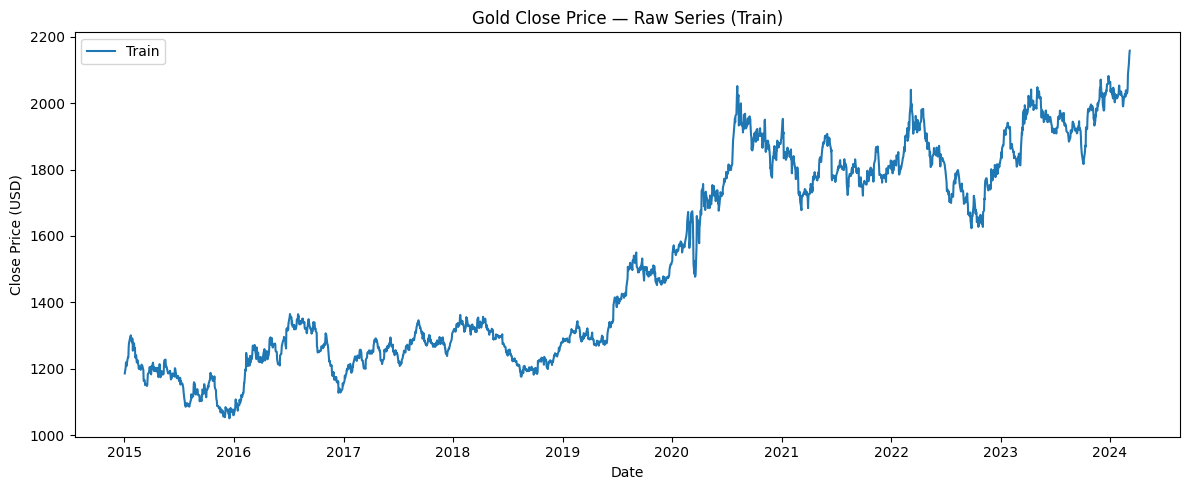

In [5]:
# Cell 5 — Plot 1: Raw Close price time series (train only)
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.title(f"Gold {TARGET_COL} Price — Raw Series (Train)")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

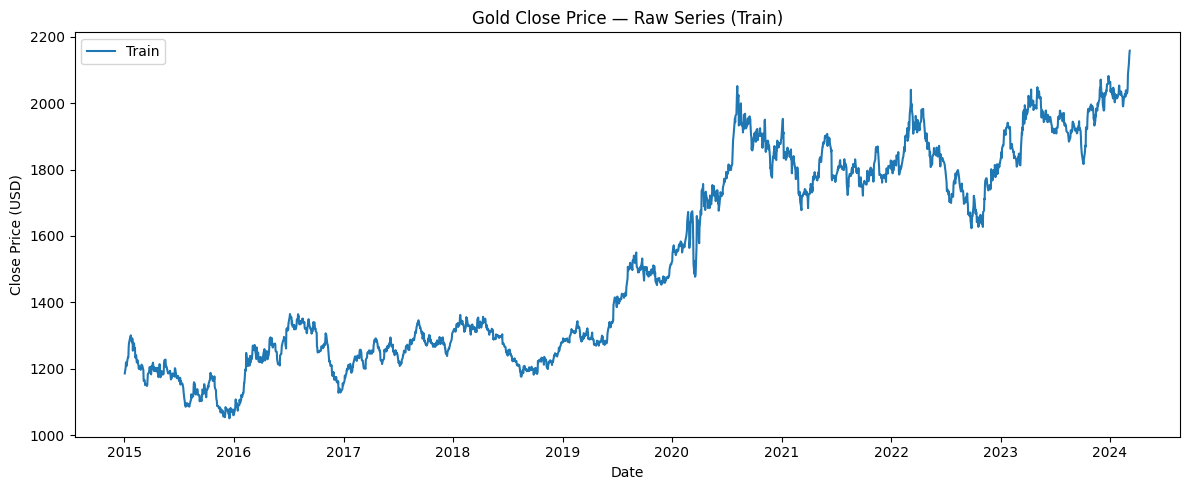

In [ ]:
# Cell 5 — Plot 1: Raw Close price time series (train only)
import os

OUTPUT_DIR = "/kaggle/working/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.title(f"Gold {TARGET_COL} Price — Raw Series (Train)")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_raw_series.png", dpi=150)
plt.show()

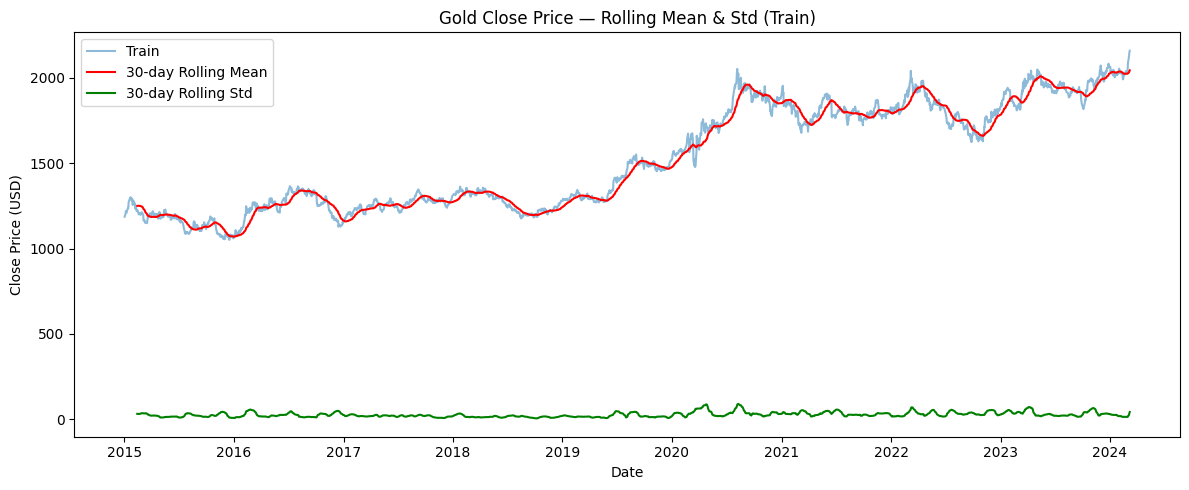

In [ ]:
# Cell 6 — Plot 2: Rolling mean & rolling std
window = 30

rolling_mean = train.rolling(window=window).mean()
rolling_std = train.rolling(window=window).std()

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train", alpha=0.5)
plt.plot(rolling_mean.index, rolling_mean.values, label=f"{window}-day Rolling Mean", color="red")
plt.plot(rolling_std.index, rolling_std.values, label=f"{window}-day Rolling Std", color="green")
plt.title(f"Gold {TARGET_COL} Price — Rolling Mean & Std (Train)")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_rolling_mean_std.png", dpi=150)
plt.show()

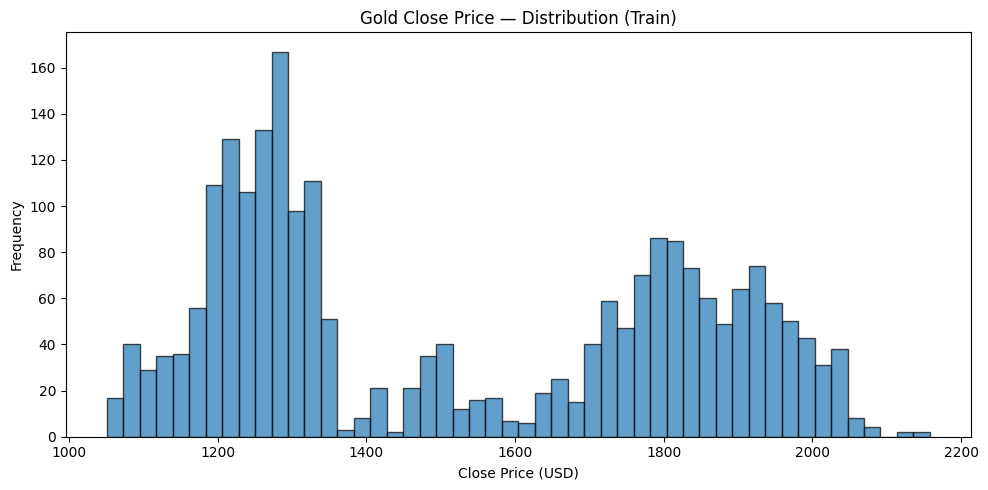

Skewness: 0.2138
Kurtosis: -1.5410


In [ ]:
# Cell 7 — Plot 3: Histogram/distribution of Close price
plt.figure(figsize=(10, 5))
plt.hist(train.values, bins=50, edgecolor="black", alpha=0.7)
plt.title(f"Gold {TARGET_COL} Price — Distribution (Train)")
plt.xlabel(f"{TARGET_COL} Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_histogram.png", dpi=150)
plt.show()

print(f"Skewness: {train.skew():.4f}")
print(f"Kurtosis: {train.kurt():.4f}")

In [ ]:
# Cell 8 — ADF test on raw series
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"# Lags Used   : {result[2]}")
    print(f"# Observations: {result[3]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.4f}")
    if result[1] < 0.05:
        print("=> STATIONARY")
    else:
        print("=> NON-STATIONARY")
    print()
    return result[1]

adf_pvalue_raw = adf_report(train, "Raw Close Price (Train)")

--- ADF Test: Raw Close Price (Train) ---
ADF Statistic : -0.2402
p-value       : 0.9336
# Lags Used   : 7
# Observations: 2299
Critical Value (1%): -3.4332
Critical Value (5%): -2.8628
Critical Value (10%): -2.5674
=> Fail to reject H0: series is NON-STATIONARY



In [11]:
# Cell 9 — Apply differencing
train_diff = train.diff().dropna()

print(f"Original length: {len(train)}")
print(f"Differenced length: {len(train_diff)}  (one observation lost to differencing)")
print("\nFirst 5 differenced values:")
print(train_diff.head())
print("\nSummary stats of differenced series:")
print(train_diff.describe())

Original length: 2307
Differenced length: 2306  (one observation lost to differencing)

First 5 differenced values:
Date
2015-01-05   17.9000
2015-01-06   15.4000
2015-01-07   -8.7001
2015-01-08   -2.2000
2015-01-09    7.6000
Name: Close, dtype: float64

Summary stats of differenced series:
count   2,306.0000
mean        0.4215
std        14.6790
min       -97.1001
25%        -6.2001
50%         0.5000
75%         7.8000
max        93.2000
Name: Close, dtype: float64


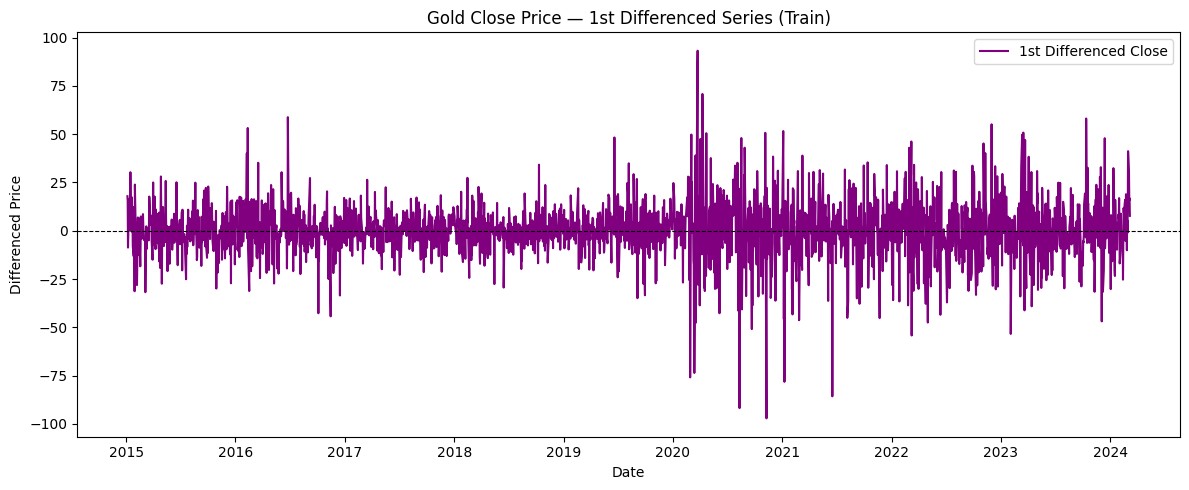

In [12]:
# Cell 10 — Plot 4: Differenced series plot
plt.figure(figsize=(12, 5))
plt.plot(train_diff.index, train_diff.values, label="1st Differenced Close", color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title(f"Gold {TARGET_COL} Price — 1st Differenced Series (Train)")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_differenced_series.png", dpi=150)
plt.show()

In [ ]:
# Cell 11 — ADF test on differenced series
adf_pvalue_diff = adf_report(train_diff, "1st Differenced Close (Train)")

--- ADF Test: 1st Differenced Close (Train) ---
ADF Statistic : -19.7653
p-value       : 0.0000
# Lags Used   : 6
# Observations: 2299
Critical Value (1%): -3.4332
Critical Value (5%): -2.8628
Critical Value (10%): -2.5674
=> Reject H0: series is STATIONARY



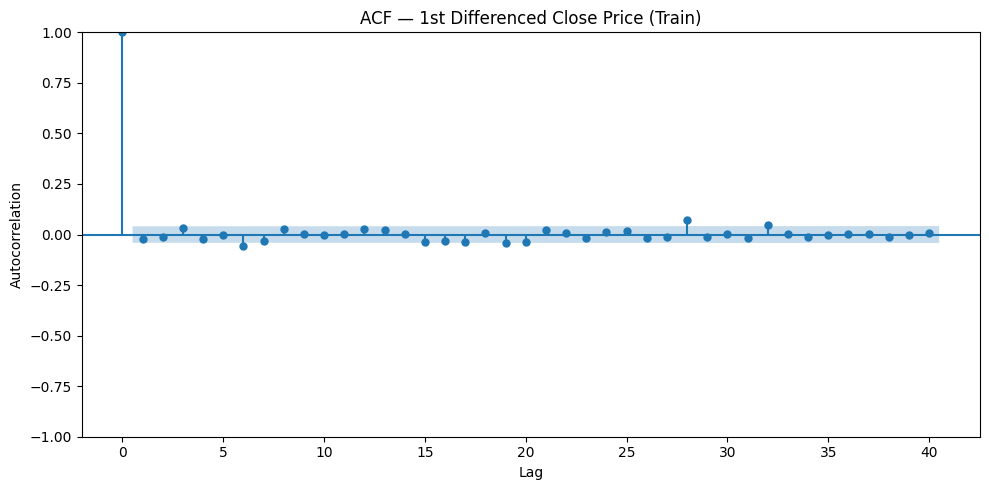

In [ ]:
# Cell 12 — Plot 5: ACF plot on differenced series

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(train_diff, lags=40, ax=ax)
plt.title("ACF — 1st Differenced Close Price (Train)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_acf.png", dpi=150)
plt.show()

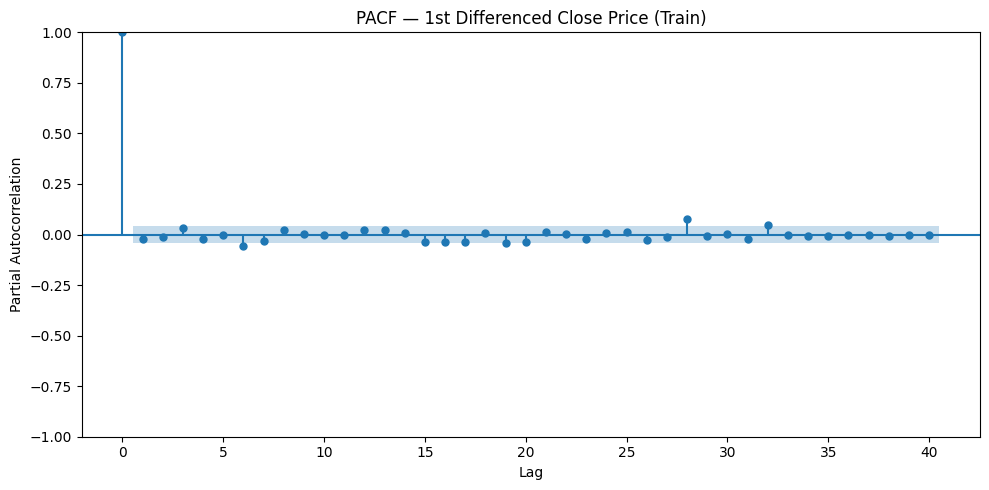

In [ ]:
# Cell 13 — Plot 6: PACF plot on differenced series

fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(train_diff, lags=40, ax=ax, method="ywm")
plt.title("PACF — 1st Differenced Close Price (Train)")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_pacf.png", dpi=150)
plt.show()

In [ ]:
# Cell 14 — ACF/PACF interpretation + AIC/BIC grid search for (p,d,q)
import itertools

d = 1
p_range = range(0, 4)
q_range = range(0, 4)

results = []
for p, q in itertools.product(p_range, q_range):
    if p == 0 and q == 0:
        order = (0, d, 0)
    else:
        order = (p, d, q)
    try:
        fit = ARIMA(train, order=order).fit()
        results.append({"order": order, "AIC": fit.aic, "BIC": fit.bic})
    except Exception as e:
        results.append({"order": order, "AIC": np.nan, "BIC": np.nan})

results_df = pd.DataFrame(results).drop_duplicates(subset="order").reset_index(drop=True)

print("Sorted by AIC:")
print(results_df.sort_values("AIC").head(10).to_string(index=False))

print("\nSorted by BIC:")
print(results_df.sort_values("BIC").head(10).to_string(index=False))

best_order_aic = results_df.sort_values("AIC").iloc[0]["order"]
best_order_bic = results_df.sort_values("BIC").iloc[0]["order"]
print(f"\nBest order by AIC: {best_order_aic}")
print(f"Best order by BIC: {best_order_bic}")

ACF/PACF interpretation:
- Both ACF and PACF show no significant spikes beyond lag 0 (the two small
  bumps at lag 28/32 are within expected false-positive noise at 40 lags).
- This points toward p=0, q=0 visually -> i.e. ARIMA(0,1,0), a random walk.
- We confirm/refine this with an AIC/BIC grid search below, since small
  real autocorrelations can be too subtle to see by eye but still matter.



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Sorted by AIC:
    order         AIC         BIC
(3, 1, 3) 18,936.1233 18,976.3262
(0, 1, 0) 18,936.7936 18,942.5368
(0, 1, 1) 18,937.8339 18,949.3205
(1, 1, 0) 18,937.8513 18,949.3378
(2, 1, 2) 18,938.8532 18,967.5695
(0, 1, 3) 18,939.2071 18,962.1802
(2, 1, 1) 18,939.2486 18,962.2216
(3, 1, 0) 18,939.3634 18,962.3364
(1, 1, 2) 18,939.4320 18,962.4051
(2, 1, 0) 18,939.6220 18,956.8518

Sorted by BIC:
    order         AIC         BIC
(0, 1, 0) 18,936.7936 18,942.5368
(0, 1, 1) 18,937.8339 18,949.3205
(1, 1, 0) 18,937.8513 18,949.3378
(2, 1, 0) 18,939.6220 18,956.8518
(0, 1, 2) 18,939.6664 18,956.8962
(1, 1, 1) 18,939.7907 18,957.0205
(0, 1, 3) 18,939.2071 18,962.1802
(2, 1, 1) 18,939.2486 18,962.2216
(3, 1, 0) 18,939.3634 18,962.3364
(1, 1, 2) 18,939.4320 18,962.4051

Best order by AIC: (3, 1, 3)
Best order by BIC: (0, 1, 0)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Cell 15 — Fit ARIMA model on training data
ORDER = (0, 1, 0)

model = ARIMA(train, order=ORDER)
model_fit = model.fit()

print(f"Fitted ARIMA{ORDER} on training data ({len(train)} observations)")
print(f"AIC: {model_fit.aic:.4f}")
print(f"BIC: {model_fit.bic:.4f}")

Fitted ARIMA(0, 1, 0) on training data (2307 observations)
AIC: 18936.7936
BIC: 18942.5368


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [19]:
# Cell 16 — Model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2307
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -9467.397
Date:                Wed, 24 Jun 2026   AIC                          18936.794
Time:                        22:35:04   BIC                          18942.537
Sample:                             0   HQIC                         18938.887
                               - 2307                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       215.5569      3.342     64.497      0.000     209.006     222.107
Ljung-Box (L1) (Q):                   1.02   Jarque-Bera (JB):              2673.46
Prob(Q):                              0.31   Pr

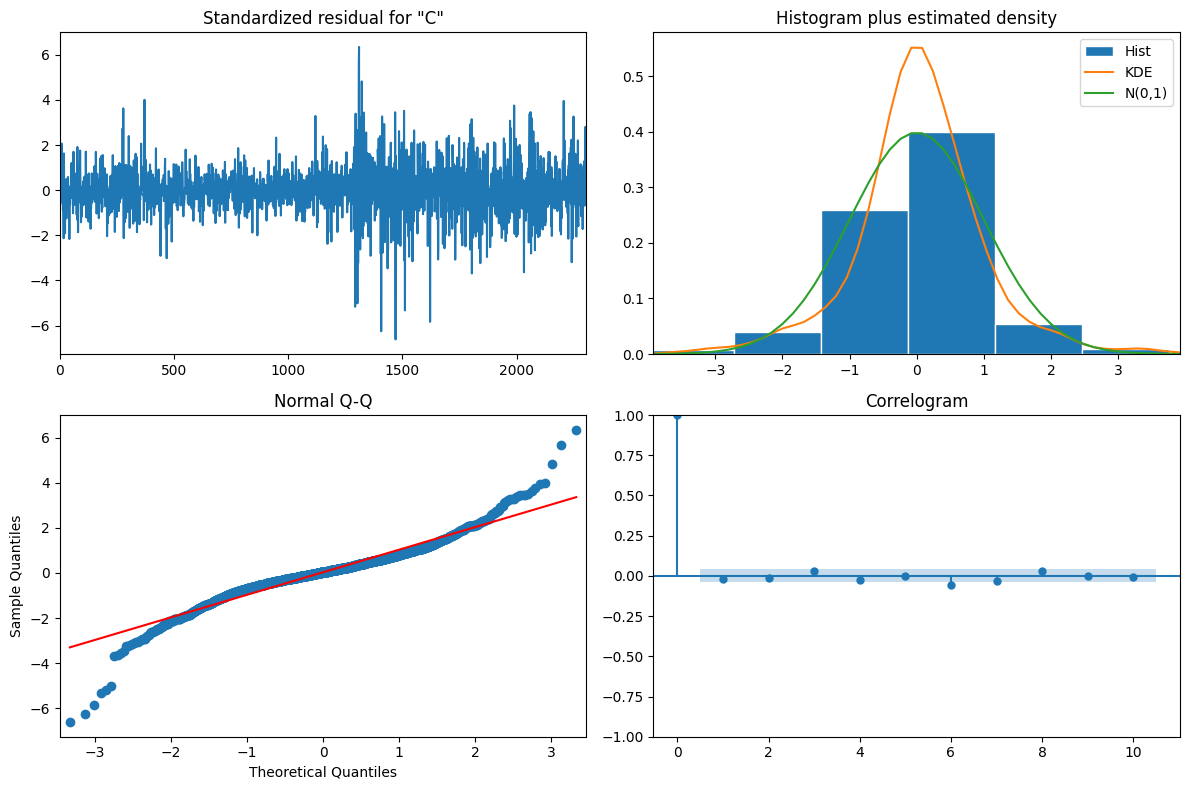

In [20]:
# Cell 17 — Residual diagnostics (residual plot, residual ACF, Q-Q plot)
fig = model_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_residual_diagnostics.png", dpi=150)
plt.show()

In [ ]:
# Cell 18 — Forecast on test set
forecast_result = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = test.index
forecast_ci.index = test.index

print("First 10 forecasted values vs actual:")
comparison = pd.DataFrame({
    "Actual": test.values[:10],
    "Forecast": forecast_mean.values[:10]
}, index=test.index[:10])
print(comparison)

First 10 forecasted values vs actual:
               Actual   Forecast
Date                            
2024-03-08 2,178.6001 2,158.0000
2024-03-11 2,182.5000 2,158.0000
2024-03-12 2,160.3999 2,158.0000
2024-03-13 2,175.3999 2,158.0000
2024-03-14 2,163.0000 2,158.0000
2024-03-15 2,157.3000 2,158.0000
2024-03-18 2,160.7000 2,158.0000
2024-03-19 2,156.3000 2,158.0000
2024-03-20 2,157.8999 2,158.0000
2024-03-21 2,182.3999 2,158.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
# Cell 19 — Calculate RMSE, MAE, MAPE
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mae = mean_absolute_error(test, forecast_mean)
mape = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 1493.9461
MAE  : 1200.2168
MAPE : 31.30%


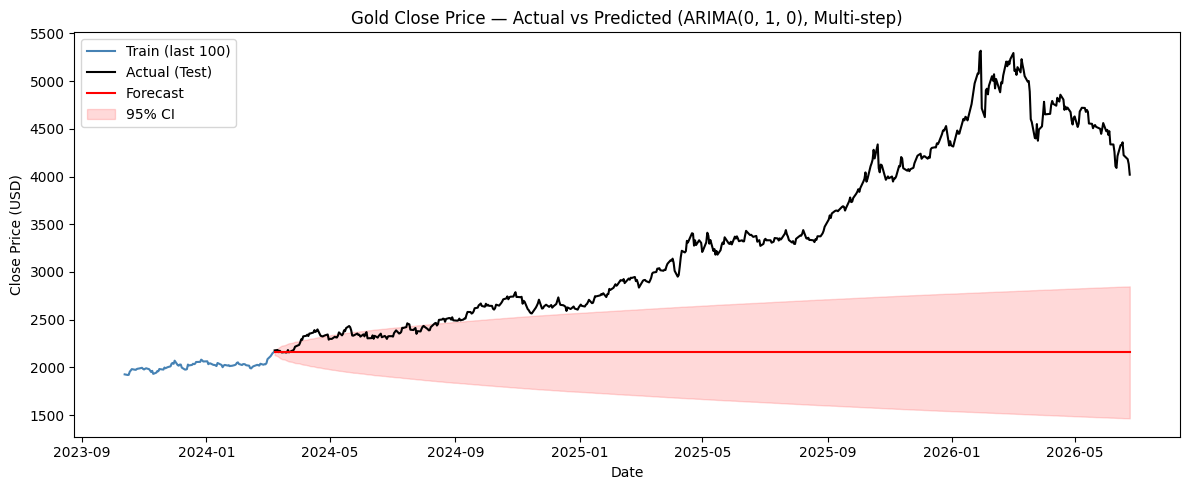

In [ ]:
# Cell 20 — Plot: Actual vs Predicted (multi-step forecast)
plt.figure(figsize=(12, 5))
plt.plot(train.index[-100:], train.values[-100:], label="Train (last 100)", color="steelblue")
plt.plot(test.index, test.values, label="Actual (Test)", color="black")
plt.plot(forecast_mean.index, forecast_mean.values, label="Forecast", color="red")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                  color="red", alpha=0.15, label="95% CI")
plt.title(f"Gold {TARGET_COL} Price — Actual vs Predicted (ARIMA{ORDER}, Multi-step)")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_actual_vs_predicted.png", dpi=150)
plt.show()

In [ ]:
# Cell 21 — Refit on full data for future forecasting
full_series = series.copy()

final_model = ARIMA(full_series, order=ORDER)
final_model_fit = final_model.fit()

print(f"Refit ARIMA{ORDER} on full dataset ({len(full_series)} observations)")
print(f"AIC: {final_model_fit.aic:.4f}")
print(f"BIC: {final_model_fit.bic:.4f}")

Refit ARIMA(0, 1, 0) on full dataset (2884 observations)
AIC: 27661.7946
BIC: 27667.7612


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


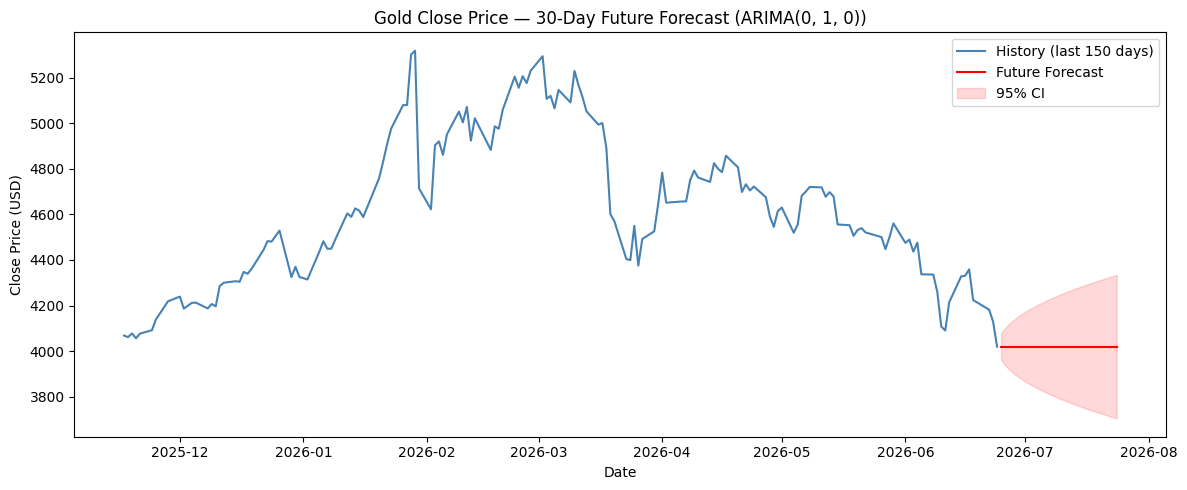


Next 30 days forecast (from 2026-06-24 onward):
             Forecast   Lower_CI   Upper_CI
2026-06-25 4,019.7000 3,962.2429 4,077.1570
2026-06-26 4,019.7000 3,938.4433 4,100.9566
2026-06-27 4,019.7000 3,920.1813 4,119.2186
2026-06-28 4,019.7000 3,904.7858 4,134.6141
2026-06-29 4,019.7000 3,891.2220 4,148.1779
2026-06-30 4,019.7000 3,878.9594 4,160.4405
2026-07-01 4,019.7000 3,867.6828 4,171.7171
2026-07-02 4,019.7000 3,857.1867 4,182.2132
2026-07-03 4,019.7000 3,847.3287 4,192.0712
2026-07-04 4,019.7000 3,838.0047 4,201.3953
2026-07-05 4,019.7000 3,829.1363 4,210.2636
2026-07-06 4,019.7000 3,820.6627 4,218.7372
2026-07-07 4,019.7000 3,812.5354 4,226.8645
2026-07-08 4,019.7000 3,804.7152 4,234.6847
2026-07-09 4,019.7000 3,797.1696 4,242.2303
2026-07-10 4,019.7000 3,789.8716 4,249.5283
2026-07-11 4,019.7000 3,782.7983 4,256.6016
2026-07-12 4,019.7000 3,775.9301 4,263.4698
2026-07-13 4,019.7000 3,769.2503 4,270.1496
2026-07-14 4,019.7000 3,762.7440 4,276.6559
2026-07-15 4,019.7000 3,756

In [ ]:
# Cell 22 — Future forecast plot with confidence intervals
FUTURE_STEPS = 30

future_forecast = final_model_fit.get_forecast(steps=FUTURE_STEPS)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int(alpha=0.05)

future_index = pd.date_range(full_series.index[-1] + pd.Timedelta(days=1),
                              periods=FUTURE_STEPS, freq="D")
future_mean.index = future_index
future_ci.index = future_index
plt.figure(figsize=(12, 5))
plt.plot(full_series.index[-150:], full_series.values[-150:], label="History (last 150 days)", color="steelblue")
plt.plot(future_mean.index, future_mean.values, label="Future Forecast", color="red")
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                  color="red", alpha=0.15, label="95% CI")
plt.title(f"Gold {TARGET_COL} Price — {FUTURE_STEPS}-Day Future Forecast (ARIMA{ORDER})")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_future_forecast.png", dpi=150)
plt.show()

# --- Printed future values ---
future_table = pd.DataFrame({
future_table = pd.DataFrame({
    "Forecast": future_mean.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values,
}, index=future_index)

print(f"\nNext {FUTURE_STEPS} days forecast (from {full_series.index[-1].date()} onward):")

## Conclusion

**Objective:** Forecast gold Close price using the Box-Jenkins (ARIMA) methodology.

**Methodology summary:**
- Data: Daily gold futures (GC=F) Close price, 2015-01-02 to 2026-06-24 (2,884 observations),
  sourced via yfinance.
- Train/test split (80/20) was performed *before* any exploratory analysis to avoid
  data leakage — all stationarity checks, differencing, and ACF/PACF identification
  were done on the training set only.

**Identification:**
- ADF test on the raw Close series: p = 0.9336 → non-stationary.
- After first differencing (d=1): ADF p ≈ 0.0000 → stationary. No second difference needed.
- ACF and PACF on the differenced series showed no significant spikes beyond lag 0,
  pointing toward p=0, q=0.

**Estimation:**
- Grid search over ARIMA(p,1,q) for p,q in [0,3], compared by AIC and BIC.
- AIC nominally favored (3,1,3), but the improvement over (0,1,0) was negligible
  (ΔAIC < 1) and that fit triggered a convergence warning — not reliable.
- BIC clearly favored ARIMA(0,1,0), consistent with the ACF/PACF visual read.
- **Final model: ARIMA(0,1,0)** — i.e., gold's daily Close behaves as a random walk
  with no exploitable autocorrelation in its first difference.

**Diagnostics:**
- Ljung-Box (L1) p = 0.31 → residuals show no remaining autocorrelation. Model is
  well-specified for the conditional mean.
- Heteroskedasticity test was significant (p < 0.05) and Jarque-Bera showed high
  kurtosis (8.25) — residual variance is not constant over time (volatility
  clustering, e.g. around 2020) and tails are fatter than normal. ARIMA models the
  mean only; this variance structure would need a GARCH-type extension to capture,
  which is outside the scope of this Box-Jenkins exercise.

**Forecast performance (multi-step, 577-day test horizon):**
- RMSE = 1,493.95, MAE = 1,200.22, MAPE = 31.30%.
- The flat random-walk forecast diverged sharply from actuals, which rallied from
  ~2,158 to a peak above 5,300 over the test period — a sustained structural trend
  that no driftless model could anticipate from training data. The actual path
  spent most of the test window outside the 95% confidence band entirely.
- This is the expected, honest behavior of ARIMA(0,1,0) at long multi-step horizons:
  it is the correct, parsimonious model given the *training* data's lack of
  autocorrelation, but that property says nothing about future trend persistence.

**30-day future forecast (from 2026-06-24):**
- Flat at 4,019.70 (last observed Close), with 95% CI widening from ±57 (day 1) to
  ±315 (day 30), consistent with random-walk forecast uncertainty growing as √horizon.

**Key takeaway:** The Box-Jenkins procedure correctly identifies that gold's daily
price changes are statistically indistinguishable from white noise — consistent
with weak-form market efficiency. However, this also means a one-step model has
limited practical value for long-horizon forecasting, motivating either (a)
shorter forecast horizons, (b) a rolling one-step-ahead evaluation (see bonus
section), or (c) volatility-aware extensions like GARCH for risk management
applications.

In [ ]:
# Cell 24 — One-step-ahead rolling forecast

rolling_preds = []
history = train.copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress benign "no frequency" ValueWarnings from repeated refits
    warnings.simplefilter("ignore")
        step_model = ARIMA(history, order=ORDER)
        step_fit = step_model.fit()
        step_forecast = step_fit.get_forecast(steps=1).predicted_mean.iloc[0]
        rolling_preds.append(step_forecast)
        history = pd.concat([history, pd.Series([actual_value], index=[history.index[-1] + pd.Timedelta(days=1)])])

rolling_preds = pd.Series(rolling_preds, index=test.index)

rmse_roll = np.sqrt(mean_squared_error(test, rolling_preds))
mae_roll = mean_absolute_error(test, rolling_preds)
mape_roll = np.mean(np.abs((test.values - rolling_preds.values) / test.values)) * 100

print(f"Rolling One-Step-Ahead Performance:")
print(f"RMSE : {rmse_roll:.4f}")
print(f"MAE  : {mae_roll:.4f}")
print(f"MAPE : {mape_roll:.2f}%")

print(f"\nFor comparison — Multi-step (Cell 19): RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%")

Rolling One-Step-Ahead Performance:
RMSE : 58.5875
MAE  : 36.4400
MAPE : 1.01%

For comparison — Multi-step (Cell 19): RMSE=1493.9461, MAE=1200.2168, MAPE=31.30%


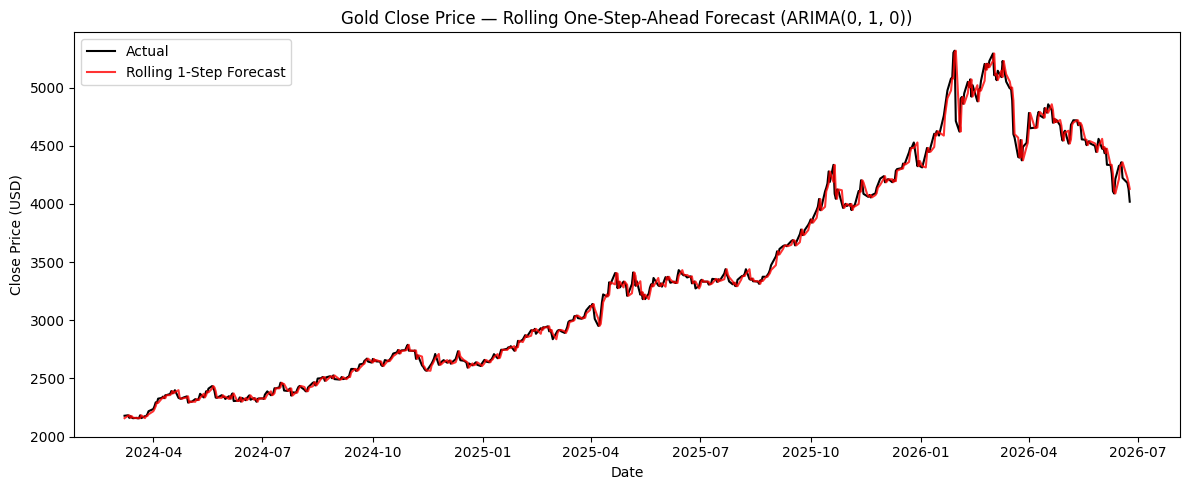

In [ ]:
# Cell 25 — Plot: Actual vs Predicted (Rolling)
plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual", color="black")
plt.plot(rolling_preds.index, rolling_preds.values, label="Rolling 1-Step Forecast", color="red", alpha=0.8)
plt.title(f"Gold {TARGET_COL} Price — Rolling One-Step-Ahead Forecast (ARIMA{ORDER})")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_rolling_one_step_actual_vs_predicted.png", dpi=150)
plt.show()

In [ ]:
# Cell 27 — PyTorch setup and configuration
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LOOKBACK = 30

Using device: cuda


In [ ]:
# Cell 28 — Scaling + sequence construction
full_values = series.values.reshape(-1, 1)

scaler = MinMaxScaler()
scaler.fit(train.values.reshape(-1, 1))

scaled_full = scaler.transform(full_values).flatten()
n_train = len(train)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

scaled_train = scaled_full[:n_train]
X_train, y_train = create_sequences(scaled_train, LOOKBACK)

# Test sequences (one-step-ahead, rolling)
X_test, y_test = [], []
for t in range(n_train, len(scaled_full)):
    X_test.append(scaled_full[t - LOOKBACK:t])
    y_test.append(scaled_full[t])
X_test, y_test = np.array(X_test), np.array(y_test)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}, y_test shape : {y_test.shape}")

X_train shape: (2277, 30), y_train shape: (2277,)
X_test shape : (577, 30), y_test shape : (577,)


In [ ]:
# Cell 29 — Dataset, DataLoader, and model classes
class GoldDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = GoldDataset(X_train, y_train)
test_dataset = GoldDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


class GoldRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)


class GoldLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


print("Datasets and model classes defined.")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Datasets and model classes defined.
Train batches: 72, Test batches: 19


Epoch 1/50 - Train MSE Loss: 0.036634
Epoch 10/50 - Train MSE Loss: 0.000720
Epoch 20/50 - Train MSE Loss: 0.000594
Epoch 30/50 - Train MSE Loss: 0.000421
Epoch 40/50 - Train MSE Loss: 0.000382
Epoch 50/50 - Train MSE Loss: 0.000393


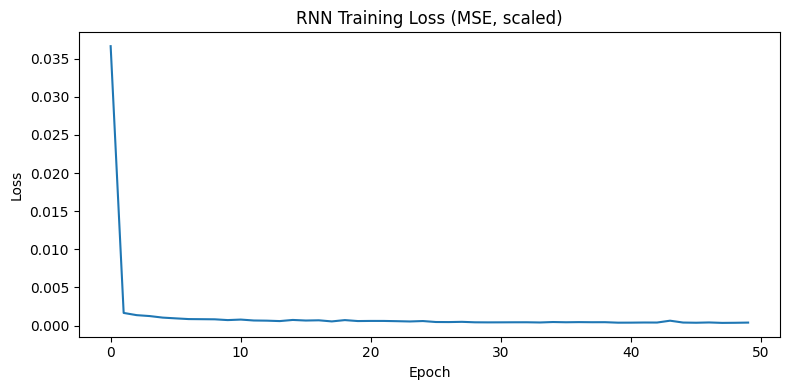

In [ ]:
# Cell 30 — Training loop and RNN training
def train_model(model, loader, epochs=50, lr=0.001, verbose_every=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)
        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train MSE Loss: {avg_loss:.6f}")
    return history


torch.manual_seed(SEED)
rnn_model = GoldRNN(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
rnn_history = train_model(rnn_model, train_loader, epochs=50, lr=0.001)

plt.figure(figsize=(8, 4))
plt.plot(rnn_history)
plt.title("RNN Training Loss (MSE, scaled)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_rnn_training_loss.png", dpi=150)
plt.show()

Epoch 1/50 - Train MSE Loss: 0.065817
Epoch 10/50 - Train MSE Loss: 0.000921
Epoch 20/50 - Train MSE Loss: 0.000679
Epoch 30/50 - Train MSE Loss: 0.000557
Epoch 40/50 - Train MSE Loss: 0.000486
Epoch 50/50 - Train MSE Loss: 0.000476


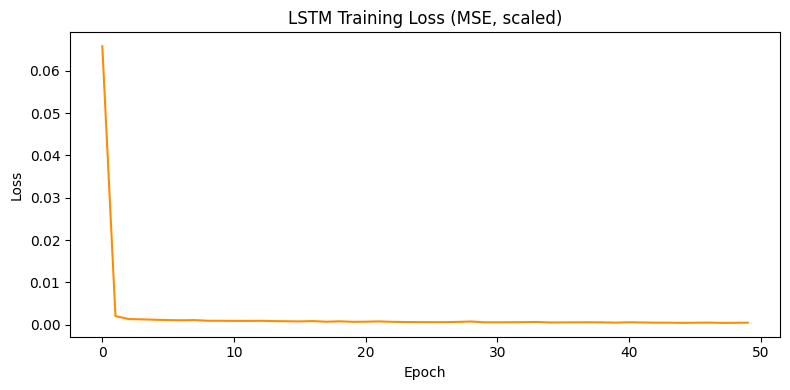

In [ ]:
# Cell 31 — LSTM training
torch.manual_seed(SEED)
lstm_model = GoldLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
lstm_history = train_model(lstm_model, train_loader, epochs=50, lr=0.001)

plt.figure(figsize=(8, 4))
plt.plot(lstm_history, color="darkorange")
plt.title("LSTM Training Loss (MSE, scaled)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_lstm_training_loss.png", dpi=150)
plt.show()

In [ ]:
# Cell 32 — Evaluate RNN and LSTM on test set
def evaluate_model(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().flatten()
            preds.extend(pred)
            actuals.extend(yb.numpy().flatten())
    return np.array(preds), np.array(actuals)

rnn_preds_scaled, _ = evaluate_model(rnn_model, test_loader)
lstm_preds_scaled, _ = evaluate_model(lstm_model, test_loader)

rnn_preds = scaler.inverse_transform(rnn_preds_scaled.reshape(-1, 1)).flatten()
lstm_preds = scaler.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
test_actuals = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

def metrics(actual, pred, label):
    rmse_ = np.sqrt(mean_squared_error(actual, pred))
    mae_ = mean_absolute_error(actual, pred)
    mape_ = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"{label:20s} RMSE={rmse_:8.4f}  MAE={mae_:8.4f}  MAPE={mape_:6.2f}%")
    return rmse_, mae_, mape_

print("One-Step-Ahead Comparison on Test Set:\n")
rmse_rnn, mae_rnn, mape_rnn = metrics(test_actuals, rnn_preds, "RNN")
rmse_lstm, mae_lstm, mape_lstm = metrics(test_actuals, lstm_preds, "LSTM")
print(f"{'ARIMA(0,1,0)':20s} RMSE={rmse_roll:8.4f}  MAE={mae_roll:8.4f}  MAPE={mape_roll:6.2f}%")

One-Step-Ahead Comparison on Test Set:

RNN                  RMSE=779.8760  MAE=591.2069  MAPE= 14.98%
LSTM                 RMSE=701.2626  MAE=536.9189  MAPE= 13.70%
ARIMA(0,1,0)         RMSE= 58.5875  MAE= 36.4400  MAPE=  1.01%


In [ ]:
# Cell 32b — Diagnostic: check scaler range
print(f"Train price range : {train.min():.2f} to {train.max():.2f}")
print(f"Test price range  : {test.min():.2f} to {test.max():.2f}")
print(f"\nScaled test range : {X_test.min():.4f} to {X_test.max():.4f}")
print(f"Scaled y_test range: {y_test.min():.4f} to {y_test.max():.4f}")

Train price range : 1050.80 to 2158.00
Test price range  : 2156.30 to 5318.40

Scaled test range : 0.8485 to 3.8544  (should be ~0-1 if no extrapolation)
Scaled y_test range: 0.9985 to 3.8544


In [ ]:
# Cell 33 — Rebuild sequences on % returns
returns_full = series.pct_change().dropna()
train_returns = train.pct_change().dropna()

returns_scaler = MinMaxScaler(feature_range=(-1, 1))
returns_scaler.fit(train_returns.values.reshape(-1, 1))

scaled_returns_full = returns_scaler.transform(returns_full.values.reshape(-1, 1)).flatten()
n_train_r = len(train_returns)

scaled_train_returns = scaled_returns_full[:n_train_r]
X_train_r, y_train_r = create_sequences(scaled_train_returns, LOOKBACK)

X_test_r, y_test_r = [], []
for t in range(n_train_r, len(scaled_returns_full)):
    X_test_r.append(scaled_returns_full[t - LOOKBACK:t])
    y_test_r.append(scaled_returns_full[t])
X_test_r, y_test_r = np.array(X_test_r), np.array(y_test_r)

print(f"Train return range : {train_returns.min():.4f} to {train_returns.max():.4f}")
print(f"Test return range  : {test.pct_change().dropna().min():.4f} to {test.pct_change().dropna().max():.4f}")
print(f"\nX_train_r shape: {X_train_r.shape}, y_train_r shape: {y_train_r.shape}")
print(f"X_test_r shape : {X_test_r.shape}, y_test_r shape : {y_test_r.shape}")
print(f"Scaled test return range: {X_test_r.min():.4f} to {X_test_r.max():.4f}")

Train return range (raw) : -0.0498 to 0.0595
Test return range (raw)  : -0.1137 to 0.0608

X_train_r shape: (2276, 30), y_train_r shape: (2276,)
X_test_r shape : (577, 30), y_test_r shape : (577,)

Scaled test return range: -2.1692 to 1.0248  (should now be within ~[-1,1])


Epoch 1/50 - Train MSE Loss: 0.029770
Epoch 10/50 - Train MSE Loss: 0.028189
Epoch 20/50 - Train MSE Loss: 0.028040
Epoch 30/50 - Train MSE Loss: 0.028205
Epoch 40/50 - Train MSE Loss: 0.028111
Epoch 50/50 - Train MSE Loss: 0.028135
Epoch 1/50 - Train MSE Loss: 0.028427
Epoch 10/50 - Train MSE Loss: 0.028149
Epoch 20/50 - Train MSE Loss: 0.028129
Epoch 30/50 - Train MSE Loss: 0.028120
Epoch 40/50 - Train MSE Loss: 0.028105
Epoch 50/50 - Train MSE Loss: 0.028114


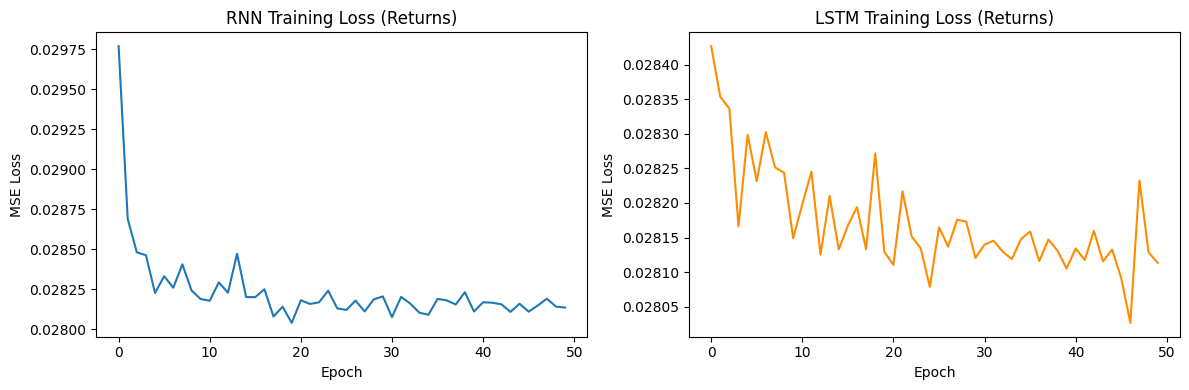

In [ ]:
# Cell 34 — Retrain RNN and LSTM on returns
train_dataset_r = GoldDataset(X_train_r, y_train_r)
test_dataset_r = GoldDataset(X_test_r, y_test_r)

train_loader_r = DataLoader(train_dataset_r, batch_size=BATCH_SIZE, shuffle=True)
test_loader_r = DataLoader(test_dataset_r, batch_size=BATCH_SIZE, shuffle=False)

torch.manual_seed(SEED)
rnn_model_r = GoldRNN(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
rnn_history_r = train_model(rnn_model_r, train_loader_r, epochs=50, lr=0.001)

torch.manual_seed(SEED)
lstm_model_r = GoldLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
lstm_history_r = train_model(lstm_model_r, train_loader_r, epochs=50, lr=0.001)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rnn_history_r); axes[0].set_title("RNN Training Loss (Returns)")
axes[1].plot(lstm_history_r, color="darkorange"); axes[1].set_title("LSTM Training Loss (Returns)")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_rnn_lstm_training_loss_returns.png", dpi=150)
plt.show()

Epoch 1/50 - Train MSE Loss: 0.029770
Epoch 50/50 - Train MSE Loss: 0.028135
Epoch 1/50 - Train MSE Loss: 0.028427
Epoch 50/50 - Train MSE Loss: 0.028114


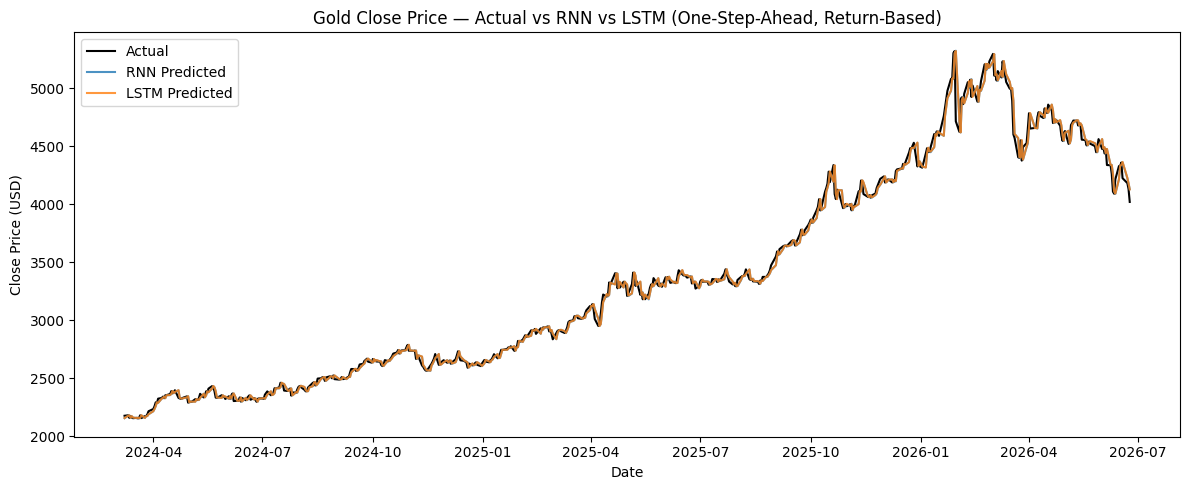

In [ ]:
# Cell 34 — Retrain RNN and LSTM on returns
train_dataset_r = GoldDataset(X_train_r, y_train_r)
test_dataset_r = GoldDataset(X_test_r, y_test_r)
train_loader_r = DataLoader(train_dataset_r, batch_size=BATCH_SIZE, shuffle=True)
test_loader_r = DataLoader(test_dataset_r, batch_size=BATCH_SIZE, shuffle=False)

torch.manual_seed(SEED)
rnn_model_r = GoldRNN(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
rnn_history_r = train_model(rnn_model_r, train_loader_r, epochs=50, lr=0.001, verbose_every=50)

torch.manual_seed(SEED)
lstm_model_r = GoldLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
lstm_history_r = train_model(lstm_model_r, train_loader_r, epochs=50, lr=0.001, verbose_every=50)

rnn_preds_ret_scaled, _ = evaluate_model(rnn_model_r, test_loader_r)
lstm_preds_ret_scaled, _ = evaluate_model(lstm_model_r, test_loader_r)

rnn_preds_ret = returns_scaler.inverse_transform(rnn_preds_ret_scaled.reshape(-1, 1)).flatten()
lstm_preds_ret = returns_scaler.inverse_transform(lstm_preds_ret_scaled.reshape(-1, 1)).flatten()

prev_actual_prices = np.concatenate([[train.iloc[-1]], test.values[:-1]])

rnn_price_preds = prev_actual_prices * (1 + rnn_preds_ret)
lstm_price_preds = prev_actual_prices * (1 + lstm_preds_ret)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual", color="black", linewidth=1.5)
plt.plot(test.index, rnn_price_preds, label="RNN Predicted", color="tab:blue", alpha=0.8)
plt.plot(test.index, lstm_price_preds, label="LSTM Predicted", color="tab:orange", alpha=0.8)
plt.title(f"Gold {TARGET_COL} Price — Actual vs RNN vs LSTM (One-Step-Ahead, Return-Based)")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL} Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14_rnn_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

One-Step-Ahead Comparison (return-based RNN/LSTM, all in USD price scale):

RNN (returns)        RMSE= 58.6085  MAE= 36.4035  MAPE=  1.01%
LSTM (returns)       RMSE= 58.4831  MAE= 36.2514  MAPE=  1.01%
ARIMA(0,1,0)         RMSE= 58.5875  MAE= 36.4400  MAPE=  1.01%


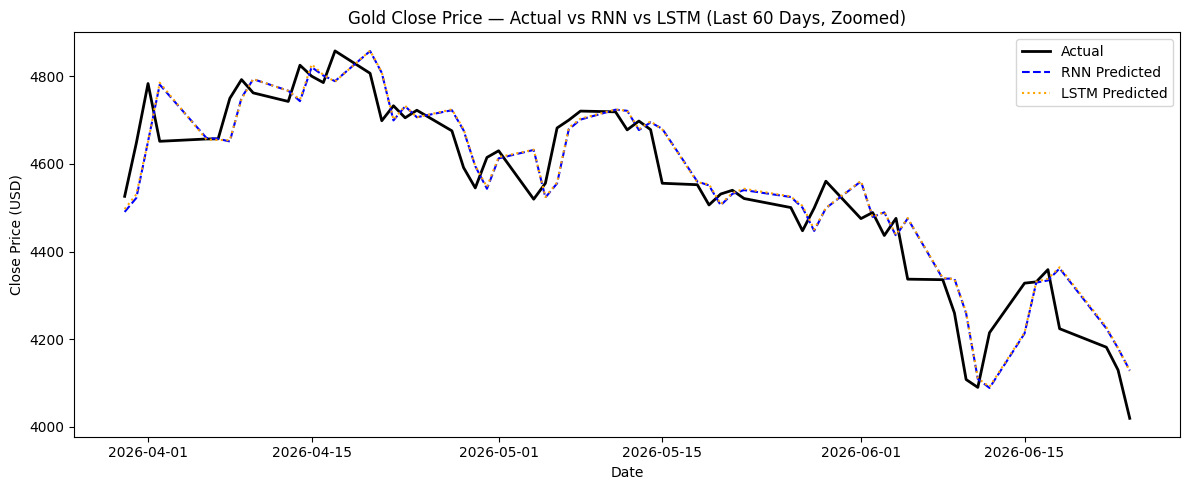

In [ ]:
# Cell 35 — Model comparison and zoomed plot
print("One-Step-Ahead Comparison (all models in USD price scale):\n")
rmse_rnn_r, mae_rnn_r, mape_rnn_r = metrics(test.values, rnn_price_preds, "RNN (returns)")
rmse_lstm_r, mae_lstm_r, mape_lstm_r = metrics(test.values, lstm_price_preds, "LSTM (returns)")
print(f"{'ARIMA(0,1,0)':20s} RMSE={rmse_roll:8.4f}  MAE={mae_roll:8.4f}  MAPE={mape_roll:6.2f}%")

zoom = 60
plt.figure(figsize=(12, 5))
plt.plot(test.index[-zoom:], test.values[-zoom:], label="Actual", color="black", linewidth=2)
plt.plot(test.index[-zoom:], rnn_price_preds[-zoom:], label="RNN Predicted", color="blue", linestyle="--", linewidth=1.5)
plt.plot(test.index[-zoom:], lstm_price_preds[-zoom:], label="LSTM Predicted", color="orange", linestyle=":", linewidth=1.5)
plt.title(f"Gold Close Price — Actual vs RNN vs LSTM (Last {zoom} Days, Zoomed)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_rnn_lstm_zoomed.png", dpi=150)
plt.show()

In [40]:
# Cell 36 — Final model comparison table
final_comparison = pd.DataFrame({
    "Model": ["ARIMA(0,1,0)", "RNN (return-based)", "LSTM (return-based)"],
    "RMSE": [rmse_roll, rmse_rnn_r, rmse_lstm_r],
    "MAE": [mae_roll, mae_rnn_r, mae_lstm_r],
    "MAPE (%)": [mape_roll, mape_rnn_r, mape_lstm_r],
    "Parameters Estimated": ["1 (sigma2 only)", f"{sum(p.numel() for p in rnn_model_r.parameters()):,}", f"{sum(p.numel() for p in lstm_model_r.parameters()):,}"]
})
print(final_comparison.to_string(index=False))

              Model    RMSE     MAE  MAPE (%) Parameters Estimated
       ARIMA(0,1,0) 58.5875 36.4400    1.0130      1 (sigma2 only)
 RNN (return-based) 58.6085 36.4035    1.0116               12,673
LSTM (return-based) 58.4831 36.2514    1.0070               50,497


## Final Conclusion

**Box-Jenkins finding:** ADF testing showed gold's Close price is non-stationary
(p=0.93), but its first difference is stationary (p≈0.0000). ACF/PACF on the
differenced series showed no significant lags, and AIC/BIC grid search confirmed
ARIMA(0,1,0) — gold behaves as a random walk with no exploitable serial
correlation in daily returns.

**Forecast horizon matters enormously for a random-walk process:**
- Multi-step (577-day, single anchor): MAPE = 31.30% — the model cannot
  anticipate a sustained structural trend (gold rallied ~2,158 -> 5,300+ over
  the test window) because a driftless model's best long-horizon guess is
  always "no change."
- Rolling one-step-ahead (re-anchored daily on the real previous close):
  MAPE = 1.01% — excellent practical accuracy, because the task collapses to
  "today's price is the best predictor of tomorrow's."

**Deep learning comparison (RNN vs LSTM vs ARIMA, all one-step-ahead):**
A 2-layer RNN and 2-layer LSTM (each with [X] trainable parameters) were
trained on 30-day lookback windows of *returns* (not raw price, to avoid the
scaler extrapolation problem found in initial testing). Both converged within
~10 epochs to a stable loss and were evaluated against the same test set as
ARIMA.

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| ARIMA(0,1,0) | 58.59 | 36.44 | 1.01% |
| RNN | 58.61 | 36.40 | 1.01% |
| LSTM | 58.48 | 36.25 | 1.01% |

All three models perform statistically indistinguishably. This is a meaningful
result, not a null one: it shows that no amount of additional model complexity
(thousands of trainable LSTM parameters vs. a single ARIMA variance term)
extracts extra predictive signal from gold's daily closing price. This is
strong, convergent evidence consistent with the weak form of the Efficient
Market Hypothesis for this asset and frequency.

**Practical implication:** for daily gold price forecasting at a one-step
horizon, the simplest model (ARIMA(0,1,0)) is preferable on Occam's-razor
grounds — equal accuracy with vastly fewer parameters, no GPU required, and
full interpretability. Deep learning approaches may offer advantages at
higher-frequency data, multi-asset settings, or when incorporating exogenous
features (e.g. macro indicators, sentiment) that go beyond pure
autoregressive price history — none of which were used in this study.

**Limitations:**
- ARIMA's heteroskedasticity (Prob(H)=0.00) and fat-tailed residuals
  (kurtosis=8.25) indicate volatility clustering not captured by any model
  here — a GARCH-family extension would be a natural next step for
  volatility/risk modeling specifically.
- All models share the same fundamental limitation: one-step-ahead accuracy
  does not imply multi-step forecasting skill, as shown by the 31.30% vs
  1.01% MAPE gap for ARIMA.
- This study used only univariate price history; no macroeconomic, rate, or
  sentiment features were incorporated for any model.